In [1]:
!pip install scikit-uplift

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.2 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.model_selection import train_test_split
from sklift.datasets import fetch_x5
import pandas as pd
from sklift.metrics import uplift_at_k
from sklift.viz import plot_uplift_preds, plot_qini_curve
from sklift.models import SoloModel
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt 
import seaborn as sns
from sklift.models import ClassTransformation

In [4]:
dataset = fetch_x5()
dataset.data.keys()

Part 1: X5 train:   0%|          | 0.00/1.18M [00:00<?, ?iB/s]

Part 2: X5 clients:   0%|          | 0.00/7.64M [00:00<?, ?iB/s]

Part 3: X5 purchases:   0%|          | 0.00/670M [00:00<?, ?iB/s]

dict_keys(['clients', 'train', 'purchases'])

In [6]:
dataset.data['clients']
df = dataset.data['clients'].merge(dataset.data['purchases'], on='client_id').drop(columns=['trn_sum_from_red','product_id'])
df

,client_id,first_issue_date,first_redeem_date,age,gender,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_quantity,trn_sum_from_iss
0,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,2.0,80.0
1,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,1.0,65.0
2,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,1.0,24.0
3,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,2.0,50.0
4,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,1.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45786563,fffff6ce77,2017-08-03 20:25:12,2017-08-26 16:41:41,42,U,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,1.0,164.0
45786564,fffff6ce77,2017-08-03 20:25:12,2017-08-26 16:41:41,42,U,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,1.0,134.0
45786565,fffff6ce77,2017-08-03 20:25:12,2017-08-26 16:41:41,42,U,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,1.0,60.0
45786566,fffff6ce77,2017-08-03 20:25:12,2017-08-26 16:41:41,42,U,48f6d115ce,2019-03-15 17:47:02,6.7,0.0,0.0,0.0,676.0,5ec64bdccb,1.0,48.0


In [7]:
agg_df = df.groupby(['client_id', 'first_issue_date','first_redeem_date', 'age', 'gender', 'store_id'], as_index=False)[ #'transaction_datetime', 'store_id'
    [
        'regular_points_received',
        'express_points_received',
        'regular_points_spent',
        'express_points_spent',
        'purchase_sum',
        'product_quantity'
    ]
].sum()

agg_df

,client_id,first_issue_date,first_redeem_date,age,gender,store_id,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,product_quantity
0,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,017c89b915,140.0,0.0,0.0,0.0,15362.00,19.0
1,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,54a4a11a29,190.0,0.0,0.0,0.0,19133.00,21.0
2,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,ed8d2683fd,62.7,0.0,0.0,0.0,6314.00,14.0
3,000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F,116ef2dfce,9.1,0.0,0.0,0.0,1862.00,7.0
4,000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F,3c6c3b17f2,89.7,0.0,0.0,0.0,12556.00,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1094548,ffff3dfff8,2018-11-01 16:06:52,2018-12-07 17:33:47,56,F,3465db4011,1040.7,0.0,-728.0,0.0,65810.71,120.0
1094549,ffffaab9da,2017-08-25 18:43:24,2017-12-08 17:53:19,23,F,46972d1c44,394.9,0.0,-66.0,0.0,41092.00,95.0
1094550,fffff6ce77,2017-08-03 20:25:12,2017-08-26 16:41:41,42,U,5ec64bdccb,568.7,0.0,-2708.0,0.0,43654.00,102.0
1094551,fffff6ce77,2017-08-03 20:25:12,2017-08-26 16:41:41,42,U,6e4faad02e,1545.8,0.0,0.0,0.0,130543.31,157.0


In [8]:
df_clients = agg_df.copy().set_index("client_id") #dataset.data['clients'].set_index("client_id")
df_train = pd.concat([dataset.data['train'], dataset.treatment , dataset.target], axis=1).set_index("client_id")
test_index = pd.Index(set(df_clients.index) - set(df_train.index))
df_clients

,first_issue_date,first_redeem_date,age,gender,store_id,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,product_quantity
client_id,,,,,,,,,,,
000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,017c89b915,140.0,0.0,0.0,0.0,15362.00,19.0
000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,54a4a11a29,190.0,0.0,0.0,0.0,19133.00,21.0
000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U,ed8d2683fd,62.7,0.0,0.0,0.0,6314.00,14.0
000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F,116ef2dfce,9.1,0.0,0.0,0.0,1862.00,7.0
000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F,3c6c3b17f2,89.7,0.0,0.0,0.0,12556.00,29.0
...,...,...,...,...,...,...,...,...,...,...,...
ffff3dfff8,2018-11-01 16:06:52,2018-12-07 17:33:47,56,F,3465db4011,1040.7,0.0,-728.0,0.0,65810.71,120.0
ffffaab9da,2017-08-25 18:43:24,2017-12-08 17:53:19,23,F,46972d1c44,394.9,0.0,-66.0,0.0,41092.00,95.0
fffff6ce77,2017-08-03 20:25:12,2017-08-26 16:41:41,42,U,5ec64bdccb,568.7,0.0,-2708.0,0.0,43654.00,102.0


In [9]:
pd.crosstab(df_train.treatment_flg, df_train.target, normalize='index')

target,0,1
treatment_flg,,
0,0.396720,0.603280
1,0.363489,0.636511


In [10]:
# Извлечение признаков
df_features = df_clients.copy()
df_features['first_issue_time'] = pd.to_datetime(df_features['first_issue_date']).astype('int64') // 10**9
df_features['first_redeem_time'] = pd.to_datetime(df_features['first_redeem_date']).astype('int64') // 10**9
#df_features['transaction_time'] = pd.to_datetime(df_features['transaction_datetime']).astype('int64') // 10**9
df_features = df_features.drop(['first_issue_date', 'first_redeem_date'], axis=1) #'transaction_datetime'
df_features['issue_redeem_delay'] = df_features.first_redeem_time - df_features.first_issue_time
df_train = df_train.merge(df_features, left_index=True, right_index=True, how='inner')
df_train

,treatment_flg,target,age,gender,store_id,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,product_quantity,first_issue_time,first_redeem_time,issue_redeem_delay
client_id,,,,,,,,,,,,,,
000012768d,0,1,45,U,017c89b915,140.0,0.0,0.0,0.0,15362.00,19.0,1501947648,1515094207,13146559
000012768d,0,1,45,U,54a4a11a29,190.0,0.0,0.0,0.0,19133.00,21.0,1501947648,1515094207,13146559
000012768d,0,1,45,U,ed8d2683fd,62.7,0.0,0.0,0.0,6314.00,14.0,1501947648,1515094207,13146559
000036f903,1,1,72,F,116ef2dfce,9.1,0.0,0.0,0.0,1862.00,7.0,1491832463,1492951076,1118613
000036f903,1,1,72,F,3c6c3b17f2,89.7,0.0,0.0,0.0,12556.00,29.0,1491832463,1492951076,1118613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffe0ed719,0,1,69,U,da2e59c0ae,530.0,0.0,0.0,0.0,69245.47,152.0,1505465604,1513090212,7624608
fffea1204c,0,1,73,F,9f2495132e,123.0,0.0,-160.0,0.0,19706.43,111.0,1517417977,1520874147,3456170
fffff6ce77,0,1,42,U,5ec64bdccb,568.7,0.0,-2708.0,0.0,43654.00,102.0,1501791912,1503765701,1973789


In [55]:
# Формируем X, y, treatment для всей обучающей выборки
X = df_train.drop(columns=['target', 'treatment_flg'])
y = df_train['target']
treatment = df_train['treatment_flg']

# Разбиваем на train и val
X_train, X_val, y_train, y_val, treat_train, treat_val = train_test_split(
    X, y, treatment, test_size=0.3, random_state=2
)

X_test = df_features.loc[test_index, :]

cat_attrs = ['gender', 'store_id'] #'store_id'

models_results = {
    'approach': [],
    'uplift@30%_train': [],
    'uplift@30%_val': []
}

In [56]:
def draw_graphs(model, uplift, y_val=y_val, treat_val=treat_val):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
    plot_qini_curve(y_true=y_val, uplift=uplift, treatment=treat_val, perfect=False, ax=ax3);
    sns.histplot(model.trmnt_preds_, label='Treatment', color='blue', ax=ax1)
    sns.histplot(model.ctrl_preds_, label='Control', color='orange', ax=ax1)
    ax1.legend()
    ax1.set_title('Распределения вероятностей')
    ax1.set_xlabel('Вероятность')
    ax1.set_ylabel('Плотность')
    sns.histplot(uplift, color='green', ax=ax2)
    ax2.set_title('Распределение uplift (разница)')
    ax2.set_xlabel('Uplift')
    ax2.set_ylabel('Плотность')
    plt.tight_layout()
    plt.show()

0:	total: 185ms	remaining: 55.4s
100:	total: 16.7s	remaining: 32.9s
200:	total: 32.6s	remaining: 16s
299:	total: 49.1s	remaining: 0us


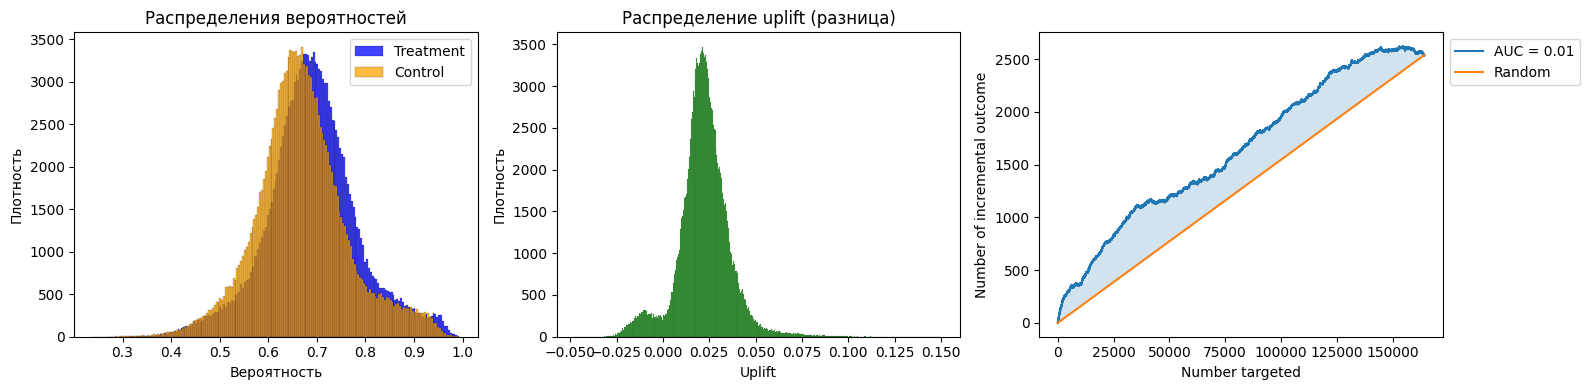

In [57]:
sm = SoloModel(CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42))
sm = sm.fit(X_train, y_train, treat_train, estimator_fit_params={'cat_features': cat_attrs})
uplift_sm_train = sm.predict(X_train)
uplift_sm_val = sm.predict(X_val)

sm_score_train = uplift_at_k(y_true=y_train, uplift=uplift_sm_train, treatment=treat_train, strategy='by_group', k=0.3)
sm_score_val = uplift_at_k(y_true=y_val, uplift=uplift_sm_val, treatment=treat_val, strategy='by_group', k=0.3)

models_results['approach'].append('SoloModel')
models_results['uplift@30%_train'].append(sm_score_train)
models_results['uplift@30%_val'].append(sm_score_val)

# Получим условные вероятности выполнения целевого действия при взаимодействии для каждого объекта
sm_trmnt_preds = sm.trmnt_preds_
# И условные вероятности выполнения целевого действия без взаимодействия для каждого объекта
sm_ctrl_preds = sm.ctrl_preds_

# Отрисуем распределения вероятностей и их разность (uplift)
draw_graphs(sm, uplift_sm_val)

In [58]:
# Например, чтобы построить важность признаков:
sm_features = pd.DataFrame({
    'feature_name': sm.estimator.feature_names_,
    'feature_score': sm.estimator.feature_importances_
}).sort_values('feature_score', ascending=False).reset_index(drop=True)

sm_features

,feature_name,feature_score
0,first_redeem_time,51.343862
1,product_quantity,22.248137
2,regular_points_received,5.418439
3,purchase_sum,4.235018
4,first_issue_time,3.249503
5,issue_redeem_delay,3.134734
6,age,2.440689
7,express_points_spent,2.332981
8,store_id,2.202329
9,treatment,1.702414


0:	total: 175ms	remaining: 52.3s
100:	total: 15.6s	remaining: 30.7s
200:	total: 31.1s	remaining: 15.3s
299:	total: 46.5s	remaining: 0us


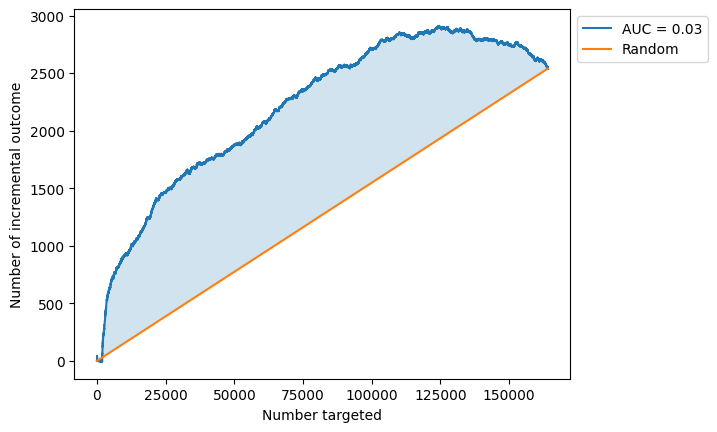

In [59]:
ct = ClassTransformation(CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42))
ct = ct.fit(X_train, y_train, treat_train, estimator_fit_params={'cat_features': cat_attrs})

uplift_ct_train = ct.predict(X_train)
uplift_ct_val = ct.predict(X_val)

ct_score_train = uplift_at_k(y_true=y_train, uplift=uplift_ct_train, treatment=treat_train, strategy='by_group', k=0.3)
ct_score_val = uplift_at_k(y_true=y_val, uplift=uplift_ct_val, treatment=treat_val, strategy='by_group', k=0.3)

models_results['approach'].append('ClassTransformation')
models_results['uplift@30%_train'].append(ct_score_train)
models_results['uplift@30%_val'].append(ct_score_val)

plot_qini_curve(y_true=y_val, uplift=uplift_ct_val, treatment=treat_val, perfect=False);

In [60]:
# Например, чтобы построить важность признаков:
ct_features = pd.DataFrame({
    'feature_name': ct.estimator.feature_names_,
    'feature_score': ct.estimator.feature_importances_
}).sort_values('feature_score', ascending=False).reset_index(drop=True)

ct_features

,feature_name,feature_score
0,first_redeem_time,68.684378
1,age,7.766248
2,issue_redeem_delay,5.646336
3,first_issue_time,5.583723
4,gender,2.780908
5,express_points_spent,2.305233
6,purchase_sum,1.861564
7,store_id,1.824907
8,product_quantity,1.440223
9,regular_points_received,1.405850


0:	total: 95.1ms	remaining: 28.4s
100:	total: 9.28s	remaining: 18.3s
200:	total: 17.7s	remaining: 8.73s
299:	total: 26.3s	remaining: 0us
0:	total: 104ms	remaining: 31s
100:	total: 9.09s	remaining: 17.9s
200:	total: 18.2s	remaining: 8.94s
299:	total: 27s	remaining: 0us


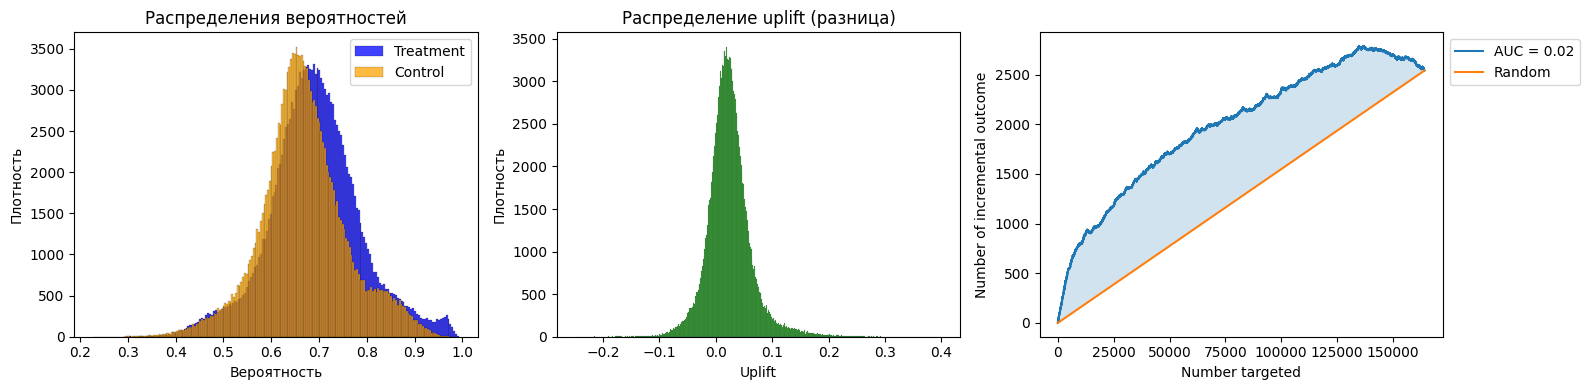

In [61]:
from sklift.models import TwoModels


tm = TwoModels(
    estimator_trmnt=CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42), 
    estimator_ctrl=CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42), 
    method='vanilla'
)
tm = tm.fit(
    X_train, y_train, treat_train,
    estimator_trmnt_fit_params={'cat_features': cat_attrs}, 
    estimator_ctrl_fit_params={'cat_features': cat_attrs}
)

uplift_tm_train = tm.predict(X_train)
uplift_tm_val = tm.predict(X_val)

tm_score_train = uplift_at_k(y_true=y_train, uplift=uplift_tm_train, treatment=treat_train, strategy='by_group', k=0.3)
tm_score_val = uplift_at_k(y_true=y_val, uplift=uplift_tm_val, treatment=treat_val, strategy='by_group', k=0.3)

models_results['approach'].append('TwoModels')
models_results['uplift@30%_train'].append(tm_score_train)
models_results['uplift@30%_val'].append(tm_score_val)

draw_graphs(tm, uplift_tm_val)

In [62]:
# Например, чтобы построить важность признаков:
tm_features = pd.DataFrame({
    'feature_name': tm.estimator_trmnt.feature_names_,
    'feature_score': tm.estimator_trmnt.feature_importances_
}).sort_values('feature_score', ascending=False).reset_index(drop=True)
tm_features

,feature_name,feature_score
0,first_redeem_time,58.743793
1,product_quantity,17.224435
2,regular_points_received,5.279327
3,purchase_sum,3.698979
4,age,3.638021
5,issue_redeem_delay,3.503661
6,first_issue_time,3.110622
7,store_id,1.545656
8,express_points_spent,1.329204
9,gender,1.113231


In [63]:
tm_features_ctrl = pd.DataFrame({
    'feature_name': tm.estimator_ctrl.feature_names_,
    'feature_score': tm.estimator_ctrl.feature_importances_
}).sort_values('feature_score', ascending=False).reset_index(drop=True)
tm_features_ctrl

,feature_name,feature_score
0,product_quantity,35.076371
1,first_redeem_time,21.987393
2,regular_points_received,10.117023
3,first_issue_time,6.246290
4,express_points_spent,5.397578
5,purchase_sum,5.248144
6,issue_redeem_delay,5.236111
7,age,3.899085
8,store_id,3.384682
9,gender,1.682930


0:	total: 93.6ms	remaining: 28s
100:	total: 8.65s	remaining: 17s
200:	total: 17.7s	remaining: 8.71s
299:	total: 26.2s	remaining: 0us
0:	total: 95.9ms	remaining: 28.7s
100:	total: 8.83s	remaining: 17.4s
200:	total: 17.6s	remaining: 8.69s
299:	total: 26.8s	remaining: 0us


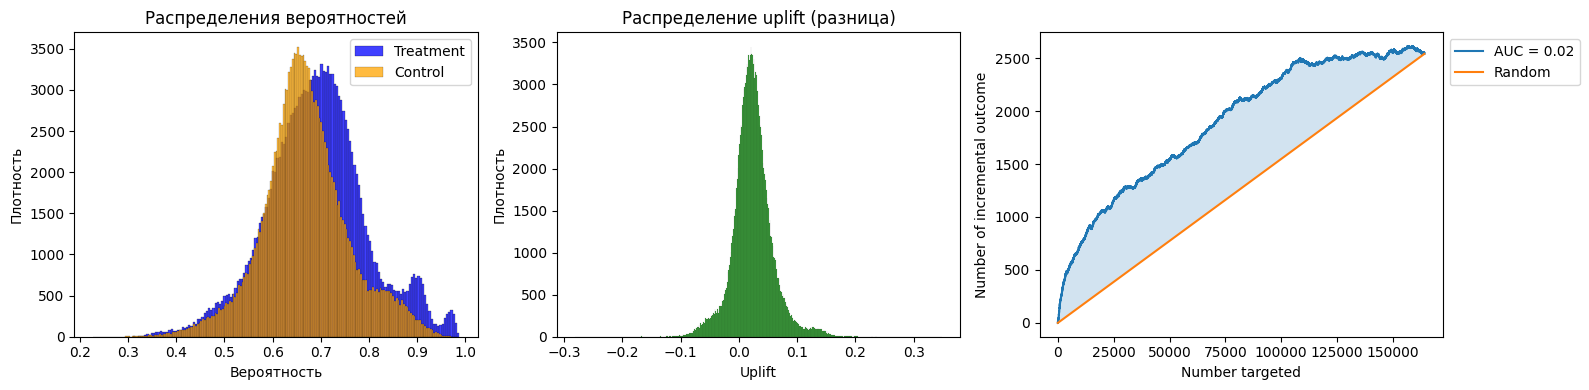

In [64]:
tm_ctrl = TwoModels(
    estimator_trmnt=CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42), 
    estimator_ctrl=CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42), 
    method='ddr_control'
)
tm_ctrl = tm_ctrl.fit(
    X_train, y_train, treat_train,
    estimator_trmnt_fit_params={'cat_features': cat_attrs}, 
    estimator_ctrl_fit_params={'cat_features': cat_attrs}
)
uplift_tm_ctrl_train = tm_ctrl.predict(X_train)
uplift_tm_ctrl_val = tm_ctrl.predict(X_val)

tm_ctrl_score_train = uplift_at_k(y_true=y_train, uplift=uplift_tm_ctrl_train, treatment=treat_train, strategy='by_group', k=0.3)
tm_ctrl_score_val = uplift_at_k(y_true=y_val, uplift=uplift_tm_ctrl_val, treatment=treat_val, strategy='by_group', k=0.3)

models_results['approach'].append('TwoModels_ddr_control')
models_results['uplift@30%_train'].append(tm_ctrl_score_train)
models_results['uplift@30%_val'].append(tm_ctrl_score_val)

draw_graphs(tm_ctrl, uplift_tm_ctrl_val)

0:	total: 99.7ms	remaining: 29.8s
100:	total: 8.82s	remaining: 17.4s
200:	total: 17.2s	remaining: 8.46s
299:	total: 26.7s	remaining: 0us
0:	total: 108ms	remaining: 32.3s
100:	total: 8.53s	remaining: 16.8s
200:	total: 16.6s	remaining: 8.18s
299:	total: 25.9s	remaining: 0us


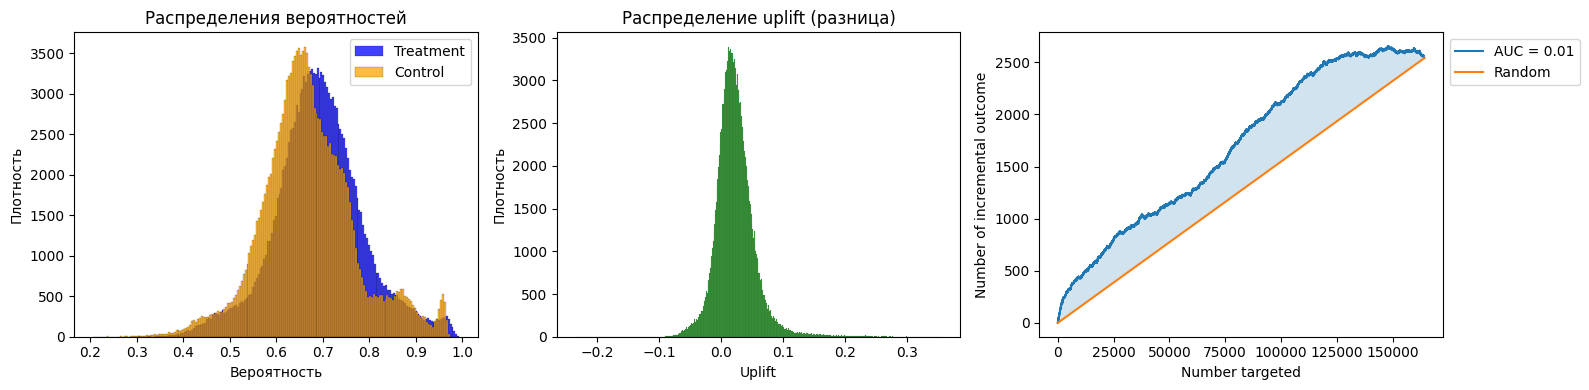

In [65]:
tm_trmnt = TwoModels(
    estimator_trmnt=CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42), 
    estimator_ctrl=CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5, random_strength=1.5, early_stopping_rounds=20, l2_leaf_reg=8, eval_metric='AUC', verbose=100, random_state=42), 
    method='ddr_treatment'
)
tm_trmnt = tm_trmnt.fit(
    X_train, y_train, treat_train,
    estimator_trmnt_fit_params={'cat_features': cat_attrs}, 
    estimator_ctrl_fit_params={'cat_features': cat_attrs}
)
uplift_tm_trmnt_train = tm_trmnt.predict(X_train)
uplift_tm_trmnt_val = tm_trmnt.predict(X_val)

tm_trmnt_score_train = uplift_at_k(y_true=y_train, uplift=uplift_tm_trmnt_train, treatment=treat_train, strategy='by_group', k=0.3)
tm_trmnt_score_val = uplift_at_k(y_true=y_val, uplift=uplift_tm_trmnt_val, treatment=treat_val, strategy='by_group', k=0.3)


models_results['approach'].append('TwoModels_ddr_treatment')
models_results['uplift@30%_train'].append(tm_trmnt_score_train)
models_results['uplift@30%_val'].append(tm_trmnt_score_val)

draw_graphs(tm_trmnt, uplift_tm_trmnt_val)

In [66]:
tm_trmnt.estimator_trmnt.tree_count_, tm_trmnt_score_train, tm_trmnt_score_val

(300, 0.11748637830103392, 0.04541071938000929)

In [67]:
tm_trmnt.estimator_trmnt.tree_count_, tm_trmnt_score_train, tm_trmnt_score_val

(300, 0.11748637830103392, 0.04541071938000929)

In [73]:
pd.DataFrame(data=models_results).sort_values('uplift@30%_val', ascending=False).reset_index(drop=True)

,approach,uplift@30%_train,uplift@30%_val
0,ClassTransformation,0.103515,0.072845
1,TwoModels,0.168533,0.066585
2,TwoModels_ddr_control,0.100129,0.061526
3,SoloModel,0.059353,0.046979
4,TwoModels_ddr_treatment,0.117486,0.045411
